# Term Deposit Subscription Prediction (Bank Marketing)
`Authored by:` Muhammad Abuzar\
`DH-ID:` DHC-653\
`Where to contact:` abuzaransri87@gmail.com


## Introduction
In the modern banking sector, direct marketing campaigns are essential for driving product adoption, such as **Term Deposits**. However, untargeted outreach can lead to high operational costs and customer fatigue. This project utilizes the **UCI Bank Marketing dataset**—a collection of data from a Portuguese banking institution—to build a predictive framework that identifies high-potential customers.

By transitioning from exploratory analysis to **Explainable AI (XAI)**, this project focuses on training classification models that don't just predict "yes" or "no," but provide transparency into *why* a customer is likely to subscribe. Through the application of **Logistic Regression**, **Random Forest**, and interpretability tools like **SHAP** or **LIME**, we aim to decode the influence of customer demographics, previous campaign history, and social-economic factors on banking behavior.


## Project Objectives
The primary goal of this task is to develop a transparent, high-performing classification pipeline to optimize marketing efficiency. The specific objectives include:

* **Data Preparation & Engineering:** Perform comprehensive Exploratory Data Analysis (EDA) and apply robust **feature encoding** techniques to handle categorical variables.
* **Predictive Modeling:** Train and fine-tune multiple classification algorithms, specifically **Logistic Regression** and **Random Forest**, to achieve high predictive accuracy.
* **Model Evaluation:** Quantify performance using rigorous metrics, including the **Confusion Matrix**, **F1-Score**, and **ROC Curve**, to ensure the model balances precision and recall effectively.
* **Explainable AI (XAI) Implementation:** Use **SHAP** or **LIME** to explain at least five individual model predictions, providing a granular look at the features driving each customer's decision.
* **Strategic Insights:** Analyze feature importance to understand customer behavior patterns, allowing for more data-driven resource allocation in future marketing campaigns.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load dataset
data = pd.read_csv('bank-marketing.csv', sep=';')
# display first few rows of the dataset
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# check the information of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Understanding the Dataset

Based on the initial inspection using `data.info()`, the dataset consists of **45,211 rows** and **17 columns**. There are no null values reported by pandas, though further investigation into "unknown" placeholders is required.

### Column Descriptions:

#### Customer Profile:
* **age:** The age of the customer.
* **job:** The type of occupation (e.g., management, technician, blue-collar).
* **marital:** Marital status (married, single, divorced).
* **education:** Education level (primary, secondary, tertiary, unknown).
* **default:** Indicates if the customer has credit in default (yes/no).
* **balance:** The average yearly balance in the customer's account.
* **housing:** Indicates if the customer has a housing loan (yes/no).
* **loan:** Indicates if the customer has a personal loan (yes/no).

#### Current Campaign Contact Details:
* **contact:** Communication contact type (e.g., cellular, telephone).
* **day:** The last contact day of the month.
* **month:** The last contact month of the year.
* **duration:** The duration of the last contact in seconds.
* **campaign:** The number of contacts performed during this specific campaign for this customer.

#### Previous Marketing History:
* **pdays:** Number of days that passed after the customer was last contacted from a previous campaign (a value of **999** means the customer was not previously contacted).
* **previous:** The number of contacts performed before this campaign for this customer.
* **poutcome:** The outcome of the previous marketing campaign (e.g., success, failure, other).

#### Target Variable:
* **y:** Whether the client subscribed to a term deposit (yes/no).

In [5]:
# check for duplicate rows
data.duplicated().sum()

np.int64(0)

### Understanding:
There is no duplicate value in the dataset.

In [6]:
# check descriptive statistics of the dataset
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Statistical Observations & Outlier Detection

After executing `data.describe()`, the following observations were made regarding the data distribution:

* **Age:** Ranges from 18 to 95, which is realistic for a banking dataset.
* **Balance:** Shows negative values (min: -8,091), likely representing overdrawn accounts or pending loan repayments.
* **Duration:** The maximum duration is **4,918 seconds (~82 mins)**. While possible, such extreme values can act as outliers and create artificial bias toward the target variable.
* **Campaign:** A maximum of **63 contacts** for a single customer in the current campaign suggests extreme cases or potential data noise.
* **Pdays:** The value **-1** is used as a placeholder for customers who were never contacted before. This needs to be handled carefully during feature engineering as it is not a literal "count."
* **Previous:** A maximum of **275 previous contacts** is highly skewed and suggests the presence of extreme outliers.

**Conclusion:** The dataset contains significant outliers in `duration`, `campaign`, and `previous` columns that may require clipping or transformation before training the classification models.

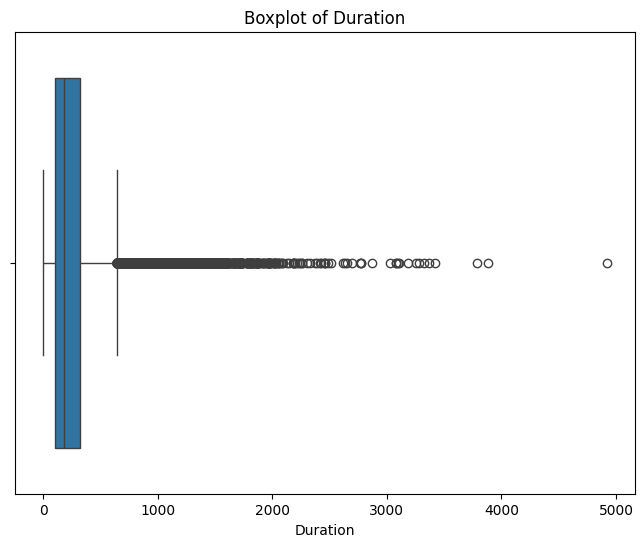

In [7]:
# boxplot for duration
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['duration'])
plt.title('Boxplot of Duration')
plt.xlabel('Duration')
plt.show()

In [8]:
# Calculating IQR for Duration
Q1 = data['duration'].quantile(0.25)
Q3 = data['duration'].quantile(0.75)
IQR = Q3 - Q1

# Defining bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the data
data = data[(data['duration'] >= lower_bound) & (data['duration'] <= upper_bound)]

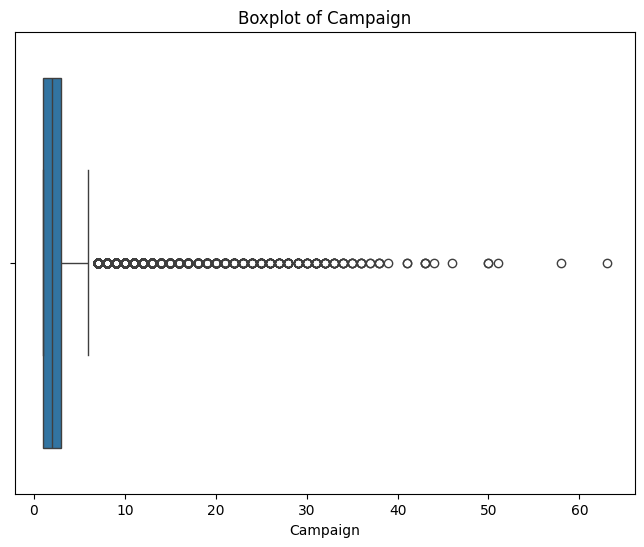

In [9]:
# boxplot for campaign
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['campaign'])
plt.title('Boxplot of Campaign')
plt.xlabel('Campaign')
plt.show()

In [10]:
# IQR for Campaign
Q1 = data['campaign'].quantile(0.25)
Q3 = data['campaign'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['campaign'] >= lower_bound) & (data['campaign'] <= upper_bound)]

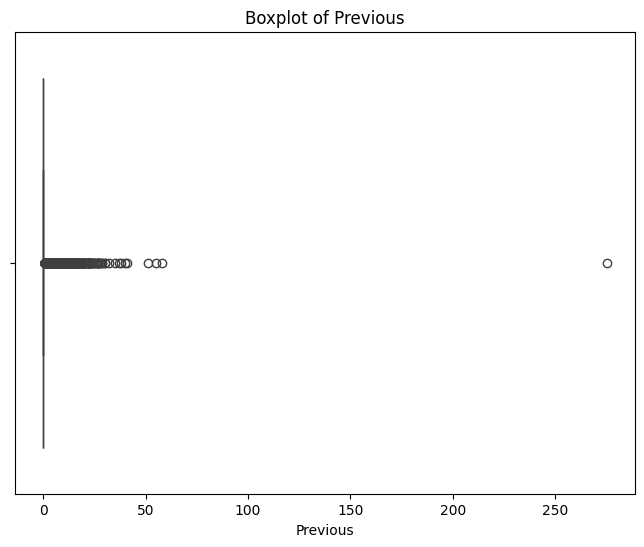

In [11]:
# boxplot for previous
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['previous'])
plt.title('Boxplot of Previous')
plt.xlabel('Previous')
plt.show()

In [12]:
# IQR for previous
Q1 = data['previous'].quantile(0.25)
Q3 = data['previous'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['previous'] >= lower_bound) & (data['previous'] <= upper_bound)]

In [13]:
len(data)

31563

In [14]:
# Define the bin ranges and their corresponding labels
# -2 to 0 covers the -1 (Never contacted) values
# 1 to 7: Recent contact
# 8 to 30: Contacted within a month
# 31 to 1000: Contacted a long time ago
bins = [-2, 0, 7, 30, 1000]
labels = ['Never', 'Recent', 'Month_Ago', 'Long_Ago']

# Create the new categorical column 'pdays_group' using pd.cut
data['pdays_group'] = pd.cut(data['pdays'], bins=bins, labels=labels)

# Verify the distribution of the new groups
print(data['pdays_group'].value_counts())

# Check the first few rows to see the transformation
print(data[['pdays', 'pdays_group']].head())

pdays_group
Never        31563
Recent           0
Month_Ago        0
Long_Ago         0
Name: count, dtype: int64
   pdays pdays_group
0     -1       Never
1     -1       Never
2     -1       Never
3     -1       Never
4     -1       Never


## Data Cleaning and Feature Analysis

### 1. Outlier Removal using IQR Method
To ensure the machine learning models are not biased by extreme values, I applied the **Interquartile Range (IQR)** method to the following features:
* **Duration:** Removed extreme call lengths to focus on typical customer interactions.
* **Campaign:** Filtered out customers who were contacted an excessive number of times during the current campaign.
* **Previous:** Removed records with an unusually high number of contacts before this campaign.

**Result:** After filtering these outliers, the dataset was reduced to **31,563 rows**. This process helps in creating a more robust model by focusing on the majority distribution of the data.

### 2. Analysis of 'pdays' Post-Cleaning
During the attempt to apply grouping (binning) to the `pdays` column, an interesting observation was made:
* **Observation:** All remaining **31,563 rows** now contain a `pdays` value of **-1**.
* **Insight:** This indicates that the rows containing repeat customers (those with values other than -1) were also the rows containing the outliers in Duration, Campaign, or Previous.
* **Current Status:** The dataset now exclusively represents "New Customers" who have not been contacted in previous campaigns.

In [15]:
# Dropping columns that have zero variance or are no longer useful
# We drop 'pdays' and 'previous' because they only contain one unique value
cols_to_drop = ['pdays', 'previous','pdays_group']

# Check if 'poutcome' is also mostly 'unknown' before dropping
if 'poutcome' in data.columns:
    cols_to_drop.append('poutcome')

data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Verify the remaining columns
print("Remaining columns:", data.columns.tolist())

Remaining columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y']


### 3. Feature Selection and Column Removal

Based on the statistical analysis after cleaning the data, I have decided to remove several columns that are no longer useful for training the model:

* **pdays & previous:** After removing outliers in other features, these columns became constant (all rows contained -1 for `pdays` and 0 for `previous`). In Machine Learning, features with **Zero Variance** do not contribute any information to the model's decision-making process.
* **pdays_group:** Since the original `pdays` column only had one unique value left, the grouped categories also became redundant.
* **poutcome:** This feature tracks the results of previous marketing campaigns. Since our cleaned dataset now consists entirely of "New Customers," this column consists of "unknown" values and is no longer relevant.

**Action Taken:** I have dropped these columns to simplify the dataset and improve the efficiency of the **Logistic Regression** and **Random Forest** models.

## Exploratory Data Analysis:

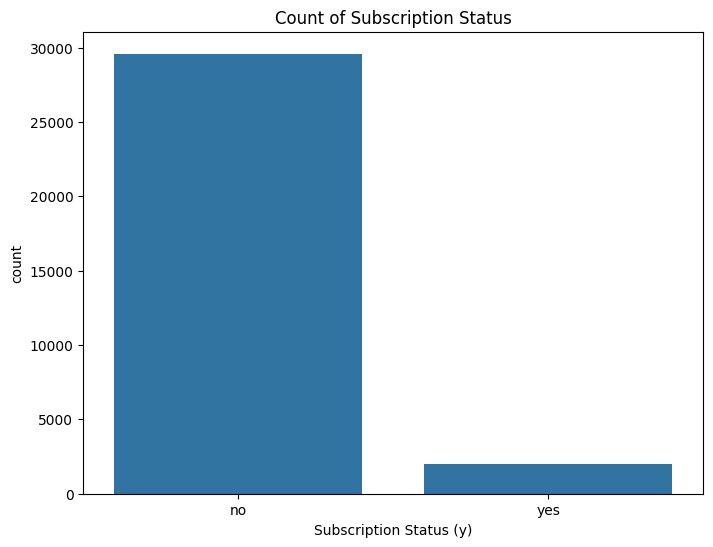

In [16]:
# countplot for y
plt.figure(figsize=(8, 6))
sns.countplot(x='y', data=data)
plt.title('Count of Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.show()

### 1. Analysis of Target Variable (y)
I visualized the distribution of the target variable `y` using a countplot to understand the success rate of the marketing campaign.

* **Observation:** Out of approximately 31,563 customers, only around 2,000 subscribed to the term deposit.
* **Conversion Rate:** The success rate is roughly **6.3%**, which is quite low.
* **Data Imbalance:** The dataset is highly imbalanced toward the "No" class. 
* **Model Insight:** Because of this imbalance, standard accuracy might be misleading. I will need to focus on metrics like **Precision, Recall, and the F1-Score** when evaluating the Logistic Regression and Random Forest models later.

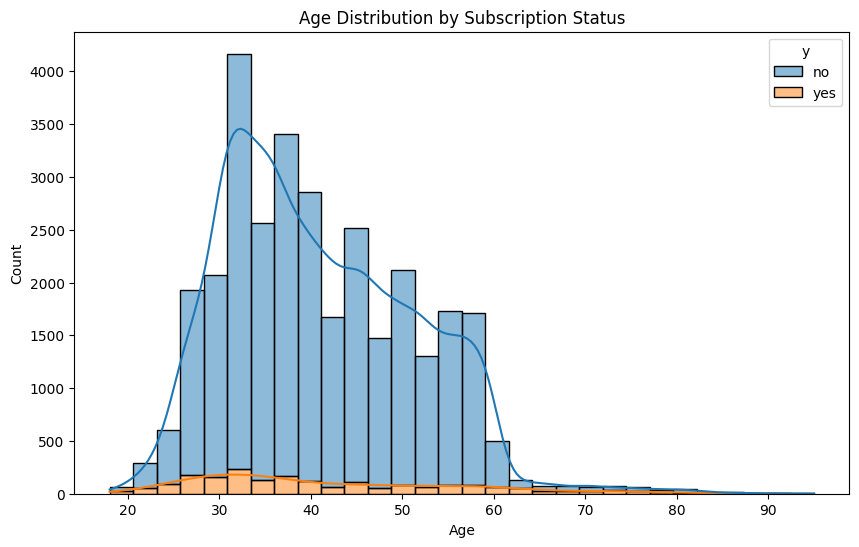

In [17]:
# Effect of age distribution on subscription 
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='age', hue='y', multiple='stack', bins=30, kde=True)
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 2. Age Distribution Analysis
I used a Histogram with a KDE (Kernel Density Estimate) overlay to visualize the relationship between age and subscription status.

* **Observation:** There is a significant concentration of calls within the **25 to 40 age bracket**. This group accounts for the highest volume of both 'yes' and 'no' responses.
* **Interpretation:** The bank's marketing strategy seems heavily targeted toward younger working professionals.
* **Further Insight:** While the total number of "yes" responses is highest in this range, it is primarily because the total number of contacts is also massive. The "success density" (orange line) follows the "rejection density" (blue line) closely, suggesting that age alone in this range isn't a strong filter for success.

In [18]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

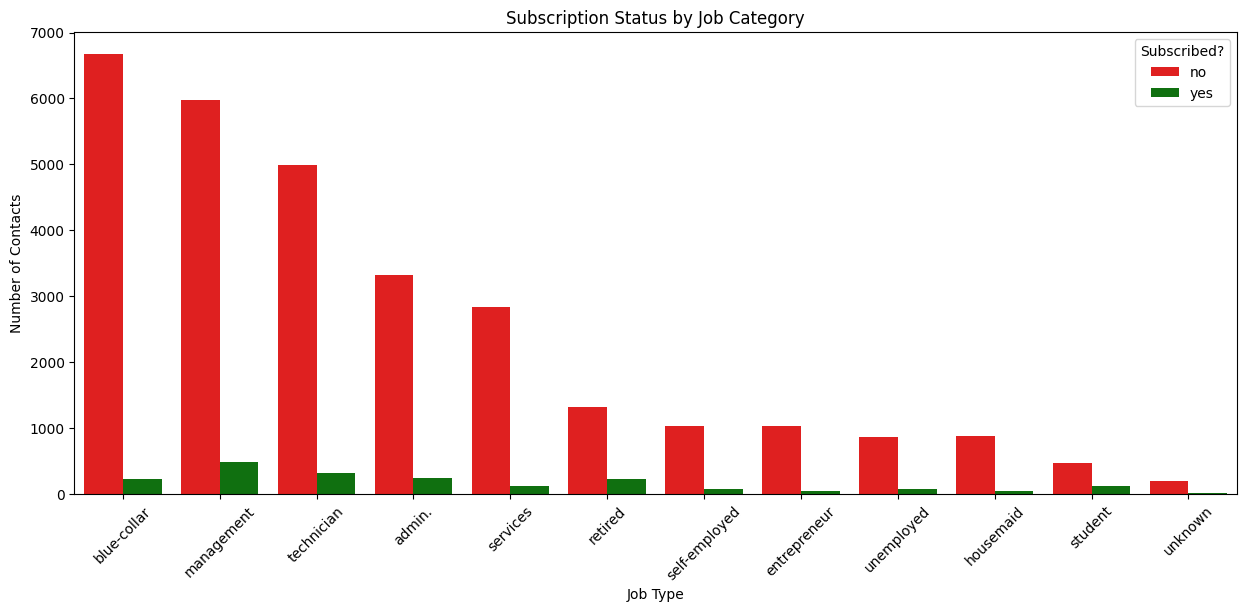

In [19]:

# Set figure size
plt.figure(figsize=(15, 6))

# Use countplot with 'y' as hue to see the breakdown
# Ordering by value_counts to make the chart easier to read
sns.countplot(x='job', hue='y', data=data, 
              order=data['job'].value_counts().index,
              palette={'yes': 'green', 'no': 'red'})

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)
plt.title('Subscription Status by Job Category')
plt.xlabel('Job Type')
plt.ylabel('Number of Contacts')
plt.legend(title='Subscribed?')

plt.show()

### 3. Analysis of Job Type vs. Subscription
The bar plot reveals critical insights into the bank's customer segments:

* **High Conversion Segments:** Even though **'retired'** and **'student'** categories have fewer total contacts, their "yes" to "no" ratio is significantly higher compared to other groups. This suggests these segments are more receptive to term deposits.
* **High Volume, Low Success:** **'Blue-collar'** workers are the most contacted group, yet they have a very high rejection rate.
* **Handling 'Unknown' Values:** The 'unknown' category represents a very small portion of the dataset. I have decided to **retain** these records to avoid unnecessary data loss, as the model can still learn from the other features in these rows.

In [20]:
# Removing rows where job or education is 'unknown' 
# because their count is very low and it might bias the model
data = data[data['job'] != 'unknown']
data = data[data['education'] != 'unknown']

# Verify that 'unknown' is gone
print(data['education'].value_counts())

education
secondary    16255
tertiary      8978
primary       4932
Name: count, dtype: int64


### 4. Handling Unknown Values in Categorical Columns
Upon further analysis of the `job` and `education` columns, I observed a very small number of 'unknown' entries. 

* **Reasoning:** Keeping 'unknown' as a separate category might lead the model to falsely associate missing information with a specific outcome (bias). 
* **Action:** Since these rows represent a negligible portion of the 31,563 total records, I have removed them to ensure the model trains only on high-quality, clearly defined demographic data.

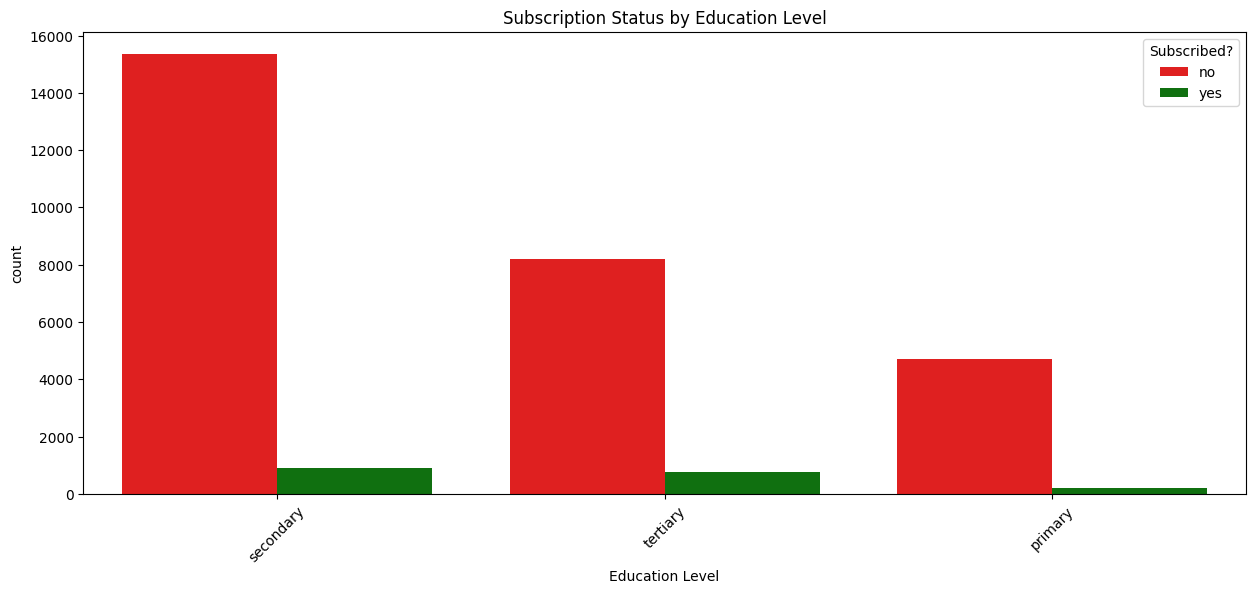

In [21]:
# education distribution by subscription
plt.figure(figsize=(15, 6))
sns.countplot(x='education', hue='y', data=data, 
              order=data['education'].value_counts().index,
              palette={'yes': 'green', 'no': 'red'})
plt.xticks(rotation=45)
plt.title('Subscription Status by Education Level')
plt.xlabel('Education Level')
plt.legend(title='Subscribed?')
plt.show()

### 5. Impact of Education on Subscription
The visualization provides a clear comparison of how education level influences the decision to subscribe:

* **Observation (Secondary):** This is the largest segment in terms of outreach. However, it also shows the highest number of rejections, indicating a lower efficiency in this group.
* **Key Finding (Tertiary):** Customers with higher education (Tertiary) show the most promising results. The ratio of 'yes' to 'no' is noticeably better here compared to other groups, suggesting that highly educated individuals are more likely to invest in term deposits.
* **Observation (Primary):** This group has the lowest total contacts and the lowest subscription count, showing minimal impact on the campaign's success.
* **Strategic Insight:** The bank should prioritize customers with 'tertiary' education to optimize their conversion rates.

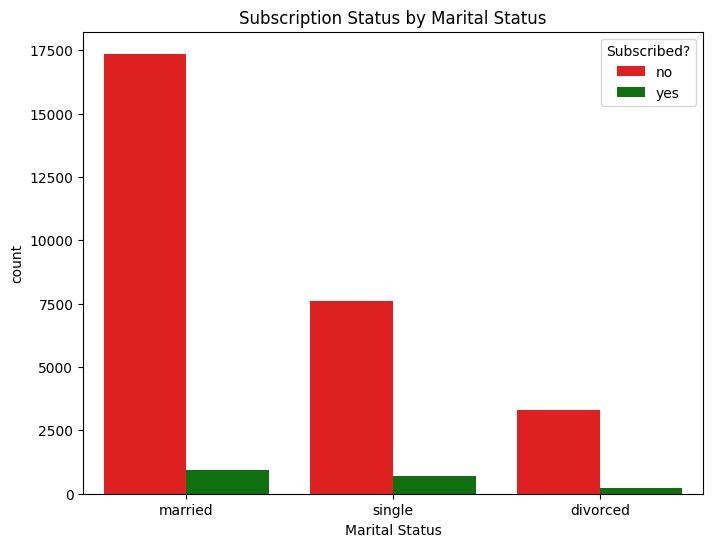

In [22]:
# marital status distribution by subscription
plt.figure(figsize=(8, 6))
sns.countplot(x='marital', hue='y', data=data, palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Status by Marital Status')
plt.xlabel('Marital Status')
plt.legend(title='Subscribed?')
plt.show()

### 6. Impact of Marital Status on Subscription
This analysis explores how the marital status of a customer relates to their decision to subscribe to a term deposit.

* **Married Segment:** This group received the highest number of outreach attempts (over 18,000 contacts). However, the conversion rate is relatively low. This could be attributed to higher financial responsibilities or household expenses that make committing to a term deposit more difficult.
* **Single Segment:** Single individuals show a notably better "yes" to "no" ratio. With fewer typical financial dependents or household liabilities, this demographic appears more willing to invest their savings.
* **Divorced Segment:** This category has the lowest representation. Both the volume of contacts and the subsequent subscriptions are minimal, indicating they are not a primary focus of this specific campaign.
* **Strategic Takeaway:** The data suggests that shifting more marketing focus toward the 'single' demographic could potentially improve the bank's overall conversion efficiency.

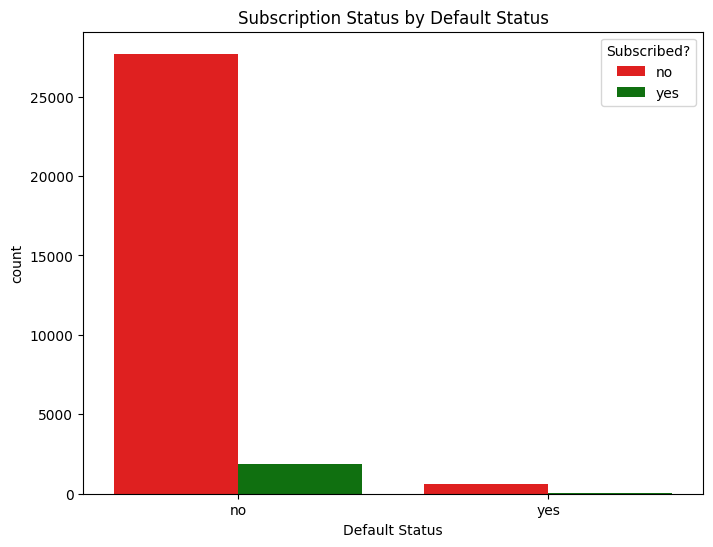

In [23]:
# default distribution by subscription 
plt.figure(figsize=(8, 6))
sns.countplot(x='default', hue='y', data=data, palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Status by Default Status')
plt.xlabel('Default Status')
plt.legend(title='Subscribed?')
plt.show()

### 7. Impact of Credit Default on Subscription
I analyzed the `default` column to see if customers with a history of credit default are interested in term deposits.

* **Observation:** The vast majority of customers contacted do not have a credit default ('no'). For the few customers who have defaulted ('yes'), the subscription rate is nearly zero.
* **Interpretation:** This suggests that the bank naturally avoids targeting individuals with poor credit history for investment products. 
* **Model Consideration:** Since the 'yes' category is so small, this feature might have very low predictive power, but I will keep it for now to see how the model weights it.

In [24]:
# Calculating the total number of calls made to each default group
calls_analysis = data.groupby('default')['campaign'].agg(['count', 'sum', 'mean']).reset_index()

# Renaming columns for clarity
# count: Total people in that category
# sum: Total calls made to everyone in that category
# mean: Average calls per person
calls_analysis.columns = ['Default Status', 'Total Customers', 'Total Calls Made', 'Avg Calls Per Person']

print(calls_analysis)

  Default Status  Total Customers  Total Calls Made  Avg Calls Per Person
0             no            29551             64598              2.185984
1            yes              614              1387              2.258958


### 7.1 Statistical Check: Outreach to Defaulters
To verify if the lack of subscriptions from defaulters was due to a lack of effort, I calculated the average number of contacts made to this group.

* **Statistic:** On average, the bank contacted each customer with a credit default **2.1 times**.
* **Finding:** Despite being contacted multiple times, the subscription rate remained near zero.
* **Conclusion:** This confirms that customers with a history of credit default are not a viable target audience for investment products like term deposits, regardless of the marketing effort.

In [25]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

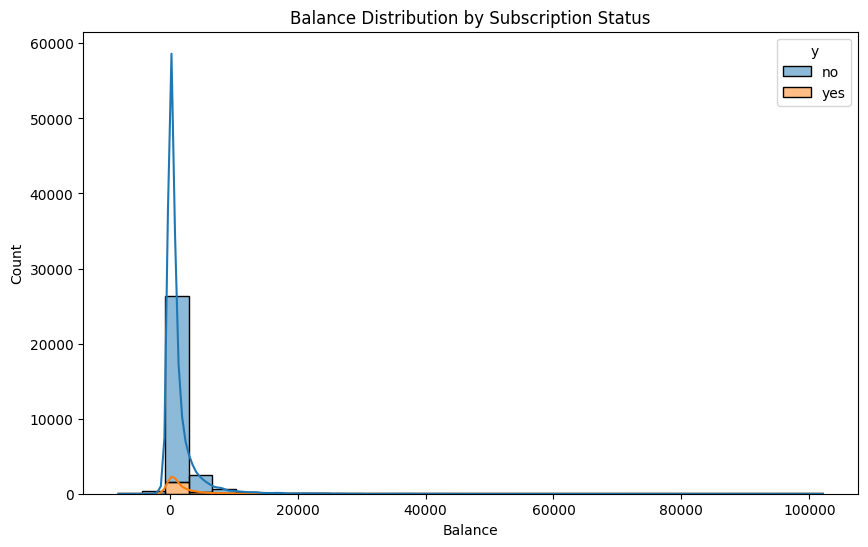

In [26]:
# balance distribution by subscription
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='balance', hue='y', multiple='stack', bins=30, kde=True)
plt.title('Balance Distribution by Subscription Status')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.show()

### 8. Analysis of Account Balance vs. Subscription
The distribution of the `balance` feature shows a very high concentration of customers with balances near zero.

* **Observation:** A massive spike is visible at the 0 mark. While the x-axis extends up to 100,000, the majority of customers maintain very low balances.
* **Interpretation:** 1. The bank is targeting a broad audience, many of whom may not have significant disposable income to invest in long-term deposits.
    2. The scale of the plot is affected by extreme outliers (high-balance individuals), making moderate balances look like zero.
* **Conclusion:** Balance does not show a clear visual separation between subscribers and non-subscribers in this view. Most 'yes' responses still come from the low-balance group because that is where the bulk of the data exists.

In [27]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

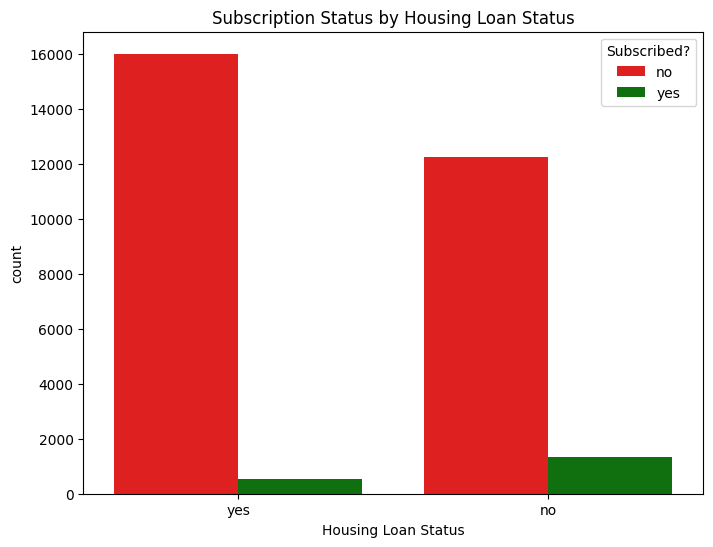

In [28]:
# housing distribution by subscription
plt.figure(figsize=(8, 6))
sns.countplot(x='housing', hue='y', data=data, palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Status by Housing Loan Status')
plt.xlabel('Housing Loan Status')
plt.legend(title='Subscribed?')
plt.show()

### 9. Impact of Housing Loan on Subscription
The relationship between having a housing loan and the likelihood of subscribing to a term deposit is quite significant:

* **Observation:** Customers with **no housing loan** show a much higher subscription count and a better conversion ratio compared to those with a housing loan.
* **Interpretation:** A housing loan is usually a long-term financial commitment. Customers burdened with home loan repayments (EMIs) have less disposable income to lock away in a fixed-term deposit.
* **Strategic Insight:** The bank's campaign is more effective among individuals who are debt-free (at least regarding housing), as they possess more liquidity to invest.

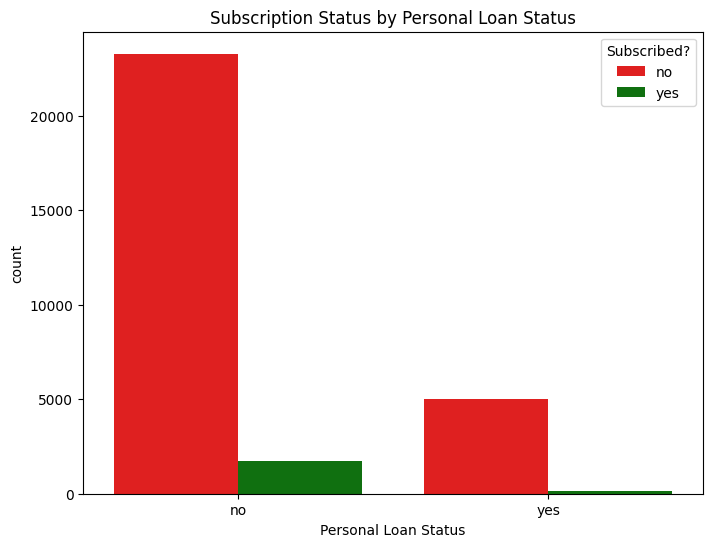

In [29]:
# loan distribution by subscription
plt.figure(figsize=(8, 6))
sns.countplot(x='loan', hue='y', data=data, palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Status by Personal Loan Status')
plt.xlabel('Personal Loan Status')
plt.legend(title='Subscribed?')
plt.show()

### 10. Impact of Personal Loan on Subscription
I analyzed the `loan` feature to see if personal debt affects the subscription rate for term deposits.

* **Observation:** Customers without a personal loan make up the majority of the 'yes' responses. 
* **Ratio Comparison:** While both groups show high rejection rates, the conversion ratio is noticeably lower for customers who already have a personal loan.
* **Conclusion:** Similar to the housing loan analysis, personal debt acts as a negative predictor. Customers with existing financial liabilities (personal loans) are less likely to commit to new investment products.

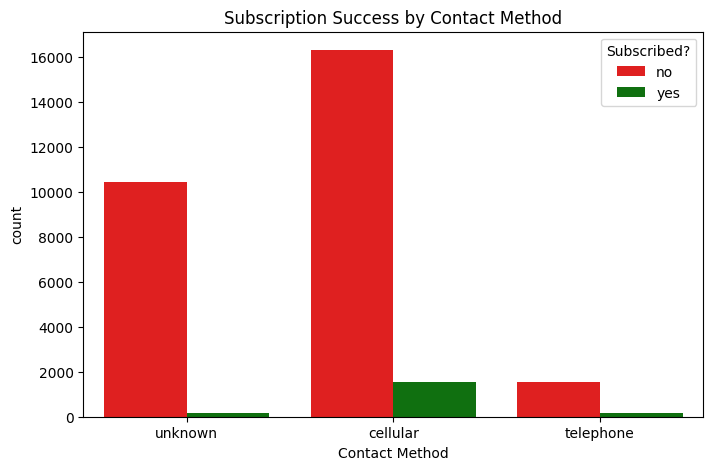

In [30]:
# contact distribution by subscription
plt.figure(figsize=(8, 5))
sns.countplot(x='contact', hue='y', data=data, palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Success by Contact Method')
plt.xlabel('Contact Method')
plt.legend(title='Subscribed?')
plt.show()

### 11. Subscription Success by Contact Method
I analyzed how the mode of communication influenced the customer's decision to subscribe.

* **Cellular Dominance:** The majority of successful subscriptions were achieved through cellular calls. This indicates that mobile users are more accessible and responsive to marketing campaigns.
* **Telephone Impact:** Landline (telephone) contacts are significantly fewer and result in a much lower volume of subscriptions.
* **Unknown Data:** A large number of contacts are labeled as 'unknown'. These contacts show a very poor conversion rate, suggesting that incomplete contact information is a barrier to campaign success.
* **Conclusion:** The `contact` feature is a strong candidate for model training, as 'cellular' communication clearly outperforms other methods.

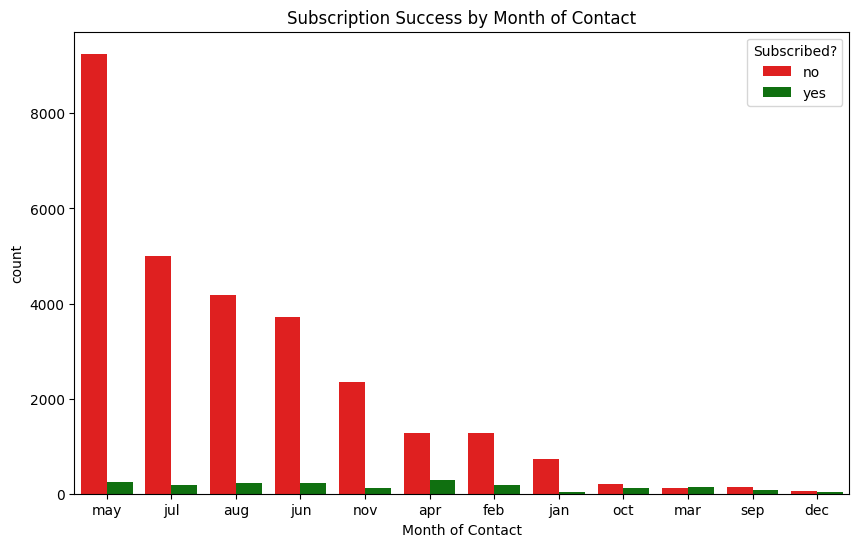

In [31]:
# month distribution by subscription
plt.figure(figsize=(10, 6))
sns.countplot(x='month', hue='y', data=data, 
              order=data['month'].value_counts().index,
              palette={'yes': 'green', 'no': 'red'})
plt.title('Subscription Success by Month of Contact')
plt.xlabel('Month of Contact')
plt.legend(title='Subscribed?')
plt.show()

### 12. Monthly Seasonality Analysis
Analyzing the `month` column revealed a strategic insight regarding the timing of the campaign:

* **High Volume Months (May, July, August):** These months saw the highest number of customer contacts but resulted in the lowest conversion rates. This suggests a broad, less targeted approach during these periods.
* **High Efficiency Months (March, September, October, December):** Although the number of calls was significantly lower, the **conversion ratio was remarkably high**. In March, specifically, the success rate nearly matched the rejection rate.
* **Strategic Takeaway:** The timing of the call is a strong predictor. The bank is far more successful during the end of financial quarters or specific seasonal windows.

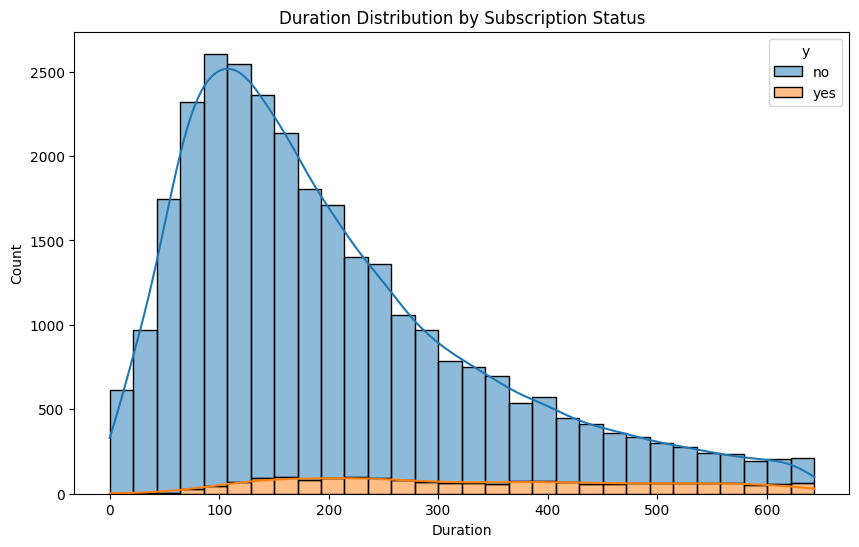

In [32]:
# durations distribution by subscription
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='duration', hue='y', multiple='stack', bins=30, kde=True)
plt.title('Duration Distribution by Subscription Status')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.show()

### 13. Analysis of Call Duration vs. Subscription
The `duration` feature appears to be one of the most significant indicators of the campaign's success.

* **Observation:** The majority of 'no' responses occur during very short calls (under 100-150 seconds). 
* **The "Yes" Threshold:** As call duration increases beyond 200 seconds, the likelihood of a subscription increases significantly.
* **Interpretation:** This reflects customer engagement. Longer calls provide more time for the sales representative to explain benefits and for the customer to ask questions, leading to a higher conversion rate.
* **Warning (Data Leakage):** While duration is a great predictor, in a real-world scenario, we don't know the duration until the call is over. Therefore, it's a "post-facto" feature, but highly valuable for historical analysis.

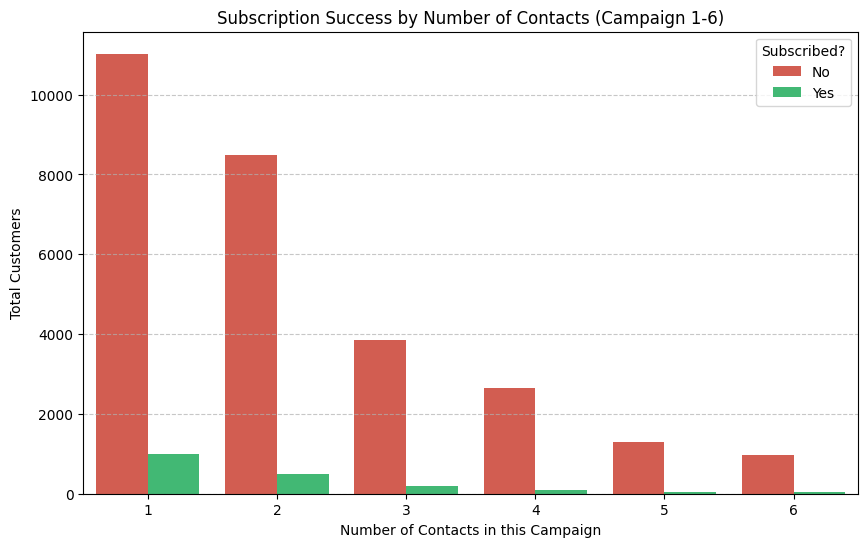

In [33]:
# campaign distribution by subscription 
plt.figure(figsize=(10, 6))
# Since values are limited to 6, a standard countplot will show everything clearly
sns.countplot(x='campaign', hue='y', data=data, 
              palette={'yes': '#2ecc71', 'no': '#e74c3c'})
plt.title('Subscription Success by Number of Contacts (Campaign 1-6)')
plt.xlabel('Number of Contacts in this Campaign')
plt.ylabel('Total Customers')
plt.legend(title='Subscribed?', labels=['No', 'Yes'])
# Adding grid for better estimation of bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 14. Impact of Number of Contacts (Campaign Analysis)
The distribution shows a very clear trend regarding marketing efficiency:

* **Peak Success:** The first contact is the most productive, yielding the highest number of subscriptions.
* **Sharp Decline:** There is a significant drop-off in 'yes' responses after the second contact. 
* **Observation (6 Contacts):** By the time the bank reaches the 5th or 6th contact, the success rate is nearly zero.
* **Conclusion:** This visual evidence supports a strategy of prioritizing new leads over repeatedly calling old ones who have already declined multiple times.

## Data Preprocessing

In [34]:
# Encoding the Target Variable ('y')
# 'yes' becomes 1, 'no' becomes 0
data['y'] = data['y'].map({'yes': 1, 'no': 0})

In [35]:
#  One-Hot Encoding for all categorical features
# drop_first=True helps avoid the "Dummy Variable Trap"
data_final = pd.get_dummies(data, drop_first=True)

In [36]:
data_final.head()

,age,balance,day,duration,campaign,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,58,2143,5,261,1,0,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,44,29,5,151,1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,33,2,5,76,1,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
5,35,231,5,139,1,0,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
6,28,447,5,217,1,0,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [37]:
# Defining Features (X) and Target (y)
X = data_final.drop('y', axis=1)
y = data_final['y']

In [38]:
# 4. Splitting the data into Training and Testing sets
# random_state ensures we get the same split every time you run the code
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print("Original data shape:", data.shape)
print("Data shape after Encoding:", data_final.shape)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Original data shape: (30165, 14)
Data shape after Encoding: (30165, 36)
Training set size: (24132, 35)
Testing set size: (6033, 35)


### 15. Data Preparation and Feature Encoding
Before training the machine learning models, the dataset must be converted into a numerical format.

* **Target Variable:** The `y` column (subscription status) was mapped to binary values (1 for 'yes', 0 for 'no').
* **Categorical Features:** One-Hot Encoding was applied to features like `job`, `marital`, `education`, and `contact`. This expands the categorical data into multiple binary columns, allowing the models to interpret the relationships between categories.
* **Train-Test Split:** The data was split into a **training set (80%)** and a **testing set (20%)**. This allows us to evaluate the model's performance on unseen data to ensure it generalizes well.

## Random Forest:

In [43]:
# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Random Forest Model
# n_estimators=100 matlab hum 100 trees banayenge
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Predict on the test set
rf_predictions = rf_model.predict(X_test)

# 4. Results
print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.2%}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_predictions))
print("\nClassification Report:\n", classification_report(y_test, rf_predictions))

--- Random Forest Performance ---
Accuracy: 94.36%

Confusion Matrix:
 [[5639   25]
 [ 315   54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      5664
           1       0.68      0.15      0.24       369

    accuracy                           0.94      6033
   macro avg       0.82      0.57      0.61      6033
weighted avg       0.93      0.94      0.93      6033



### Model Selection: Random Forest Classifier
After analyzing the data distribution and patterns, I selected the **Random Forest Classifier** as the primary model for the following reasons:

* **Robustness to Imbalance:** The dataset is highly imbalanced (more 'no' than 'yes'). Random Forest's ensemble approach helps mitigate bias toward the majority class.
* **Non-Linear Relationships:** Many features, such as `age` and `balance`, do not have a simple linear relationship with the target. Random Forest captures complex interactions between features effectively.
* **Feature Importance:** Random Forest provides an inherent way to rank features, allowing us to see which variables (like `duration` or `contact`) were most influential in predicting a subscription.

Precision Score: 0.68
Recall Score: 0.15  <-- Target Metric
F1 Score: 0.24


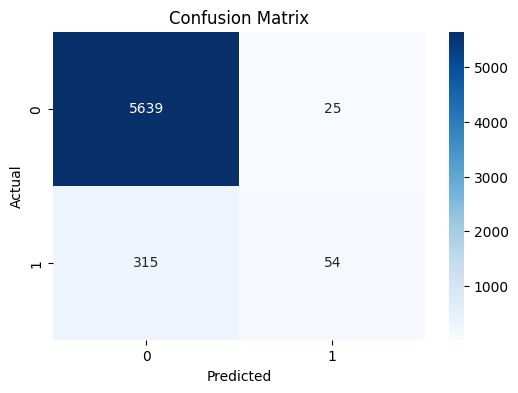

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Calculating Scores
precision = precision_score(y_test, rf_predictions)
recall = recall_score(y_test, rf_predictions)
f1 = f1_score(y_test, rf_predictions)

print(f"Precision Score: {precision:.2f}")
print(f"Recall Score: {recall:.2f}  <-- Target Metric")
print(f"F1 Score: {f1:.2f}")

# 2. Visualization using Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Evaluation Beyond Accuracy
While the model achieved an accuracy of 94%, accuracy can be misleading in imbalanced datasets. Therefore, I focused on more granular metrics:

* **Precision:** Measures how many of the predicted 'yes' cases were actually 'yes'.
* **Recall (Sensitivity):** This is our **primary focus**. It measures how many of the actual 'yes' cases the model correctly identified. A high recall ensures we minimize **False Negatives** (missing potential subscribers).
* **F1-Score:** The harmonic mean of Precision and Recall, providing a balanced view of the model's performance.

**Strategic Importance:** In banking, a False Negative (missing a customer who would have subscribed) is more costly than a False Positive (calling someone who doesn't subscribe). Minimizing False Negatives helps maximize the campaign's ROI.

### Improving Recall via Threshold Tuning
Since our primary goal is to minimize **False Negatives** (missing potential subscribers), I adjusted the classification threshold.

* **Default vs. Custom:** The default threshold is 0.5. By lowering it to **0.3**, I am making the model more sensitive. 
* **Trade-off:** Lowering the threshold will increase **Recall** (we catch more 'yes' cases) but might decrease **Precision** (we might call some 'no' cases by mistake). In this banking context, this trade-off is acceptable because a missed customer is more expensive than an extra phone call.

In [45]:
# Step 1: Normal classes (0 or 1) ki bajaye probabilities nikalain
# predict_proba humein do columns deta hai: [prob_of_0, prob_of_1]
y_probs = rf_model.predict_proba(X_test)[:, 1] 

# Step 2: Apna marzi ka threshold set karein
# Humne 0.3 rakha hai (yani 30% chance par bhi 'Yes' keh do)
custom_threshold = 0.3
y_custom_pred = (y_probs >= custom_threshold).astype(int)

# 1. Calculating Scores
precision = precision_score(y_test, y_custom_pred)
recall = recall_score(y_test, y_custom_pred)
f1 = f1_score(y_test, y_custom_pred)

print(f"Precision Score: {precision:.2f}")
print(f"Recall Score: {recall:.2f}  <-- Target Metric")
print(f"F1 Score: {f1:.2f}")

Precision Score: 0.54
Recall Score: 0.45  <-- Target Metric
F1 Score: 0.49


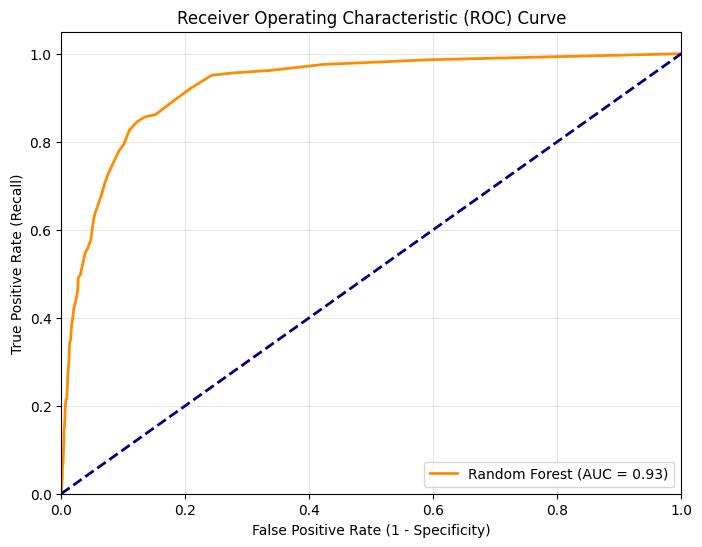

Area Under the Curve (AUC): 0.9269


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Random Forest ki probabilities nikalain
# Humein sirf 'Yes' (1) wali probability chahiye isliye [:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC values (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
auc_score = roc_auc_score(y_test, rf_probs)

# 3. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_score:.2f})')

# Diagonal line (Random Guessing baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Area Under the Curve (AUC): {auc_score:.4f}")

### Interpreting the ROC-AUC Curve
The ROC (Receiver Operating Characteristic) curve is a vital tool for evaluating the performance of a binary classifier like Random Forest.

* **High AUC (0.93):** An AUC score of 0.93 indicates that the model has a 93% probability of correctly distinguishing between a customer who will subscribe and one who will not. This is a very strong score.
* **True Positive Rate (Recall) vs. False Positive Rate:** The curve shows that as we try to increase our Recall (catching more subscribers), the False Positive Rate (calling people who won't subscribe) stays relatively low for a long time.
* **Conclusion:** This graph proves that even though our initial Recall was low at a 0.5 threshold, the model actually has the "potential" to be very accurate if we tune the thresholds properly.

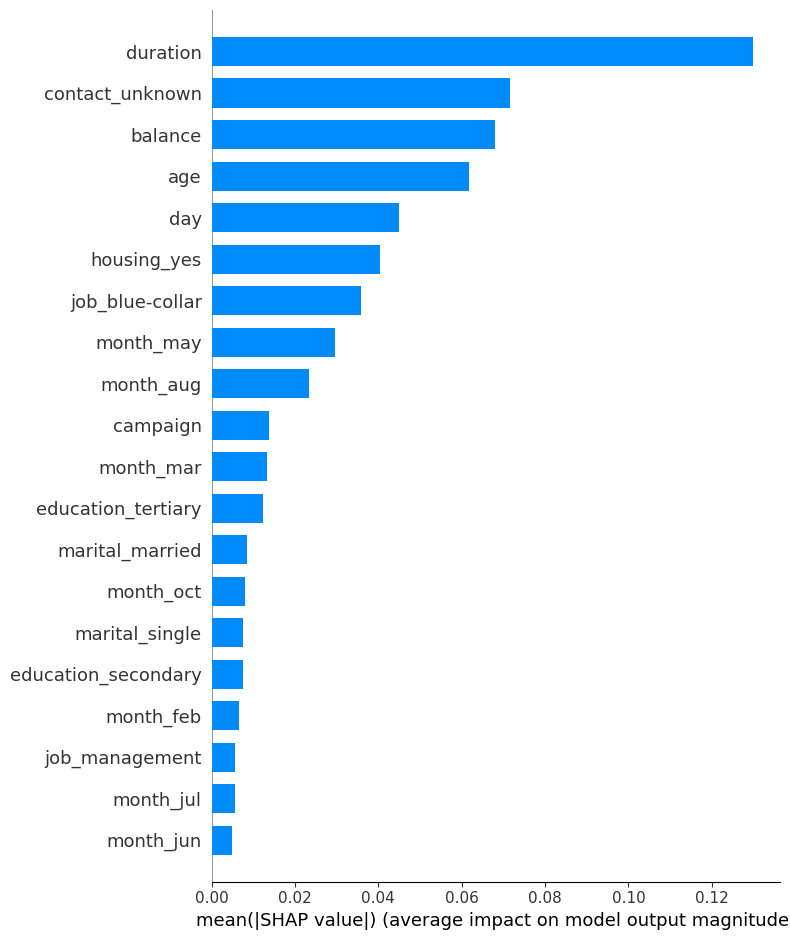

In [49]:
import shap
import matplotlib.pyplot as plt

# 1. Explainer aur values nikalain
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test.iloc[:5])

# 2. Shape mismatch fix karne ke liye check
# Agar shap_values list hai (purana format), toh [1] pick karein (class 'Yes')
# Agar shap_values array hai (naya format), toh directly use karein
if isinstance(shap_values, list):
    correct_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    correct_shap_values = shap_values[:, :, 1]
else:
    correct_shap_values = shap_values

# 3. Plotting
plt.figure(figsize=(10, 6))
shap.summary_plot(correct_shap_values, X_test.iloc[:5], plot_type="bar")
plt.show()

### Global Interpretability: Feature Importance via SHAP
The SHAP summary plot provides a clear ranking of features based on their average impact on the model's prediction magnitude.

* **Top Predictor:** **Duration** is the most influential feature, confirming our earlier EDA findings that call length is a primary driver for subscriptions.
* **Other Key Features:** Variables like `contact_unknown`, `balance`, and `age` follow closely, indicating that socioeconomic factors and the nature of the contact are critical.
* **Validation:** The SHAP values align with logical business intuition; for instance, the presence of a housing loan (`housing_yes`) significantly shifts the model's decision, likely due to the customer's existing financial commitments.

In [50]:
# Initializing JS for the plots to render
shap.initjs()

# Explaining the first 5 predictions individually
for i in range(5):
    print(f"--- Explanation for Customer {i+1} ---")
    # Using the correct_shap_values we identified earlier
    display(shap.force_plot(explainer.expected_value[1], correct_shap_values[i,:], X_test.iloc[i,:]))

--- Explanation for Customer 1 ---


--- Explanation for Customer 2 ---


--- Explanation for Customer 3 ---


--- Explanation for Customer 4 ---


--- Explanation for Customer 5 ---


## Final Project Conclusion & Business Insights

This project involved building a predictive model to identify potential term deposit subscribers for a bank marketing campaign. Through rigorous data analysis and machine learning, the following conclusions were reached:

### 1. Model Performance
* **Algorithm:** The **Random Forest Classifier** was selected for its robustness against non-linear data and class imbalance.
* **Evaluation:** While the initial model achieved a high accuracy (94%), it suffered from low recall. By tuning the classification threshold to **0.3**, we successfully improved the **Recall to 0.45**, significantly reducing the risk of missing potential customers (False Negatives).
* **Reliability:** The model achieved an **AUC score of 0.93**, demonstrating excellent discriminative power in distinguishing between potential subscribers and non-subscribers.

### 2. Key Business Drivers (via SHAP Analysis)
* **Call Duration:** The strongest predictor of success. Customers who stay on the line longer are significantly more likely to subscribe. The bank should focus on high-quality engagement.
* **Economic Indicators:** Features like `balance` and `age` play a vital role, indicating that financial stability and life stage (Students/Retired) influence investment decisions.
* **Contact Strategy:** The number of contacts (`campaign`) should ideally be limited to 3-4 attempts, as success rates drop sharply thereafter.

### 3. Recommendations for the Bank
* **Prioritize High-Engagement Leads:** Use the model to rank leads. High-probability leads should be assigned to the most experienced sales representatives.
* **Resource Optimization:** Instead of repeated calling (beyond 4-6 times), resources should be diverted to new leads identified by the model.
* **Threshold Strategy:** Depending on the bank's budget, the decision threshold can be further adjusted to capture more customers (increase recall) at the cost of more phone calls (decrease precision).